# Trabajo Práctico: Predicción de Precios de Casas

**Aprendizaje Automático 1 — Tecnicatura en Inteligencia Artificial (FCEIA)**

**Integrantes:** 
* Aiup, Agustín.
* Paoloni, Franco.
* Silva, Julián.

---

## Librerias y Dataset

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Mostramos todas las columnas y limitamos los decimales para que las tablas sean legibles.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Estilo uniforme para todos los gráficos del notebook.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Semilla global: la reutilizamos en cada paso aleatorio para que el trabajo sea reproducible.
RANDOM_STATE = 42

In [ ]:
house_pricing = pd.read_csv("../data/house-prices-tp.csv")

## Análisis Exploratorio

En esta sección se elabora un primer diagnóstico del conjunto de datos.

### Estructura General

In [25]:
house_pricing.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.072,0.000,4.490,0.000,0.449,6.121,56.800,3.748,3.000,247.000,18.500,395.150,8.440,22.200
1,0.083,0.000,13.920,0.000,0.437,6.127,18.400,5.503,4.000,289.000,16.000,396.900,8.580,23.900
2,0.128,12.500,6.070,0.000,0.409,5.885,33.000,6.498,4.000,345.000,18.900,396.900,8.790,20.900
3,0.089,21.000,5.640,0.000,0.439,5.963,45.700,6.815,4.000,243.000,16.800,395.560,13.450,19.700
4,0.114,0.000,8.560,0.000,0.520,6.781,71.300,2.856,5.000,384.000,20.900,395.580,7.670,26.500


In [ ]:
house_pricing.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


Las 14 columnas son numéricas (`float64`), por lo que **no hay variables de texto que
requieran codificación**. Sin embargo, el hecho de que todas sean `float64` no significa que
todas sean continuas: `CHAS` es binaria y `RAD` es un índice discreto. El tipo de dato con
el que `pandas` las carga no debe confundirse con la naturaleza real de la variable.

### Estadísticos Descriptivos

In [26]:
house_pricing.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,533.000,534.000,541.000,533.000,532.000,535.000,532.000,541.000,528.000,538.000,528.000,534.000,534.000,535.000
mean,5.846,13.197,11.219,0.090,0.560,6.292,67.632,3.944,9.699,409.575,18.430,347.806,13.028,22.747
std,13.829,24.903,6.942,0.287,0.119,0.782,28.462,2.256,8.684,167.689,2.195,99.636,7.580,9.491
min,0.006,0.000,0.460,0.000,0.385,3.561,2.900,1.130,1.000,187.000,12.600,0.320,1.730,5.000
25%,0.084,0.000,5.130,0.000,0.453,5.876,42.275,2.112,4.000,279.000,17.000,369.530,7.150,16.750
50%,0.315,0.000,9.690,0.000,0.538,6.208,76.500,3.340,5.000,335.000,19.000,390.815,11.465,21.200
75%,4.871,20.000,18.100,0.000,0.644,6.639,93.825,5.401,23.633,666.000,20.200,395.890,17.205,26.300
max,88.976,100.000,27.740,1.000,0.871,8.780,100.000,12.127,24.000,711.000,22.000,396.900,37.970,50.000


De esta tabla se desprenden dos cuestiones relevantes para el modelado:

- **Las escalas son muy heterogéneas**: `NOX` se mueve entre 0.385 y 0.871, mientras que `TAX`
  llega a 711 y `B` a 396.9. Esta diferencia de órdenes de magnitud es la que va a justificar
  más adelante el **escalado de los datos**, imprescindible para el gradiente descendente y
  para que la regularización penalice a todos los coeficientes de manera comparable.
- **Varias variables están fuertemente sesgadas**: en `CRIM` la media (5.85) es mucho mayor que
  la mediana (0.32) y el máximo llega a 88.98, lo que indica una distribución con cola derecha
  muy larga. Lo mismo ocurre con `ZN`, cuya mediana es 0. Lo confirmaremos con los histogramas.

### 3.3. Análisis de valores faltantes

In [10]:
# Cuantificamos los valores faltantes por columna, en términos absolutos y relativos.
faltantes = pd.DataFrame({
    "nulos": house_pricing.isna().sum(),
    "porcentaje": (house_pricing.isna().mean() * 100).round(2),
})
faltantes.sort_values("nulos", ascending=False)

,nulos,porcentaje
PTRATIO,28,5.040
RAD,28,5.040
NOX,24,4.320
AGE,24,4.320
CHAS,23,4.140
CRIM,23,4.140
LSTAT,22,3.960
B,22,3.960
ZN,22,3.960
RM,21,3.780


In [ ]:
# Totales generales: cuántos valores faltan y cuántas filas están afectadas.
total_nulos = int(house_pricing.isna().sum().sum())
filas_afectadas = int(house_pricing.isna().any(axis=1).sum())

print(f"Valores faltantes totales : {total_nulos}")
print(f"Filas con al menos un nulo: {filas_afectadas} de {len(house_pricing)} "
      f"({filas_afectadas / len(house_pricing) * 100:.2f}%)")

Ninguna columna supera el **5,1%** de faltantes, un porcentaje que aisladamente parecería
inofensivo. Sin embargo, los 306 valores faltantes se concentran en solo 50 filas: esto
significa que los nulos **no están distribuidos de manera uniforme**, sino agrupados en un
subconjunto de registros muy deteriorados. Analizamos entonces la cantidad de nulos *por fila*.

In [12]:
# Analizamos cómo se distribuyen los nulos dentro de cada fila afectada.
nulos_por_fila = house_pricing.isna().sum(axis=1)

distribucion = (nulos_por_fila[nulos_por_fila > 0]
                .value_counts()
                .sort_index()
                .rename_axis("nulos_en_la_fila")
                .reset_index(name="cantidad_de_filas"))
distribucion

,nulos_en_la_fila,cantidad_de_filas
0,1,5
1,2,3
2,3,11
3,4,3
4,5,3
5,6,2
6,7,5
7,8,4
8,9,4
9,10,1


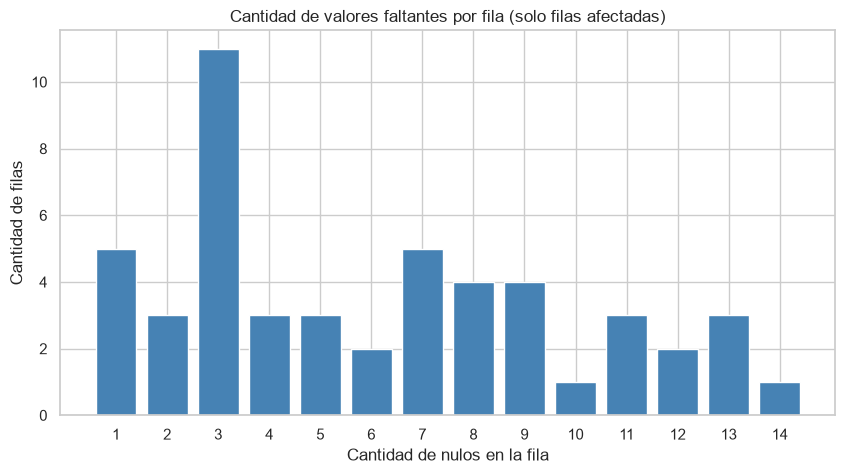

In [13]:
# Visualizamos la distribución para dimensionar la gravedad del deterioro.
plt.bar(distribucion["nulos_en_la_fila"], distribucion["cantidad_de_filas"], color="steelblue")
plt.title("Cantidad de valores faltantes por fila (solo filas afectadas)")
plt.xlabel("Cantidad de nulos en la fila")
plt.ylabel("Cantidad de filas")
plt.xticks(range(1, 15))
plt.show()

In [ ]:
# Identificamos los casos extremos: filas donde falta la mitad o más de la información.
print(f"Filas con 7 o más nulos (>= 50% de las columnas): {(nulos_por_fila >= 7).sum()}")
print(f"Filas completamente vacías (14 nulos)          : {(nulos_por_fila == 14).sum()}")

# Mostramos las filas más deterioradas para inspeccionarlas manualmente.
house_pricing.loc[nulos_por_fila.sort_values(ascending=False).head(5).index]

Este es el hallazgo más importante del diagnóstico: existen filas en las que falta **la
mitad o más** de la información, e incluso **una fila completamente vacía**. Imputar un
registro en el que se desconocen 10 de 14 variables equivale a inventar la observación
completa, lo cual introduciría ruido artificial en el entrenamiento. La decisión sobre qué
hacer con estas filas se toma en la próxima sección.

### 3.4. Valores duplicados

In [ ]:
# Verificamos la existencia de registros duplicados exactos.
print(f"Filas duplicadas exactas: {house_pricing.duplicated().sum()}")

No hay registros duplicados, por lo que no es necesario eliminar filas por esta causa.

### 3.5. Consistencia de los valores: variables discretas

In [ ]:
# Contamos los valores únicos de cada variable para detectar cuáles no son realmente continuas.
house_pricing.nunique().sort_values().rename("valores_unicos").to_frame()

`CHAS` presenta solo 2 valores únicos, consistente con su definición de variable dummy.
En cambio `RAD`, que según el diccionario es un **índice discreto de accesibilidad**,
presenta 31 valores únicos, muchos más de los esperables. Lo verificamos en detalle.

In [ ]:
# Confirmamos que CHAS solo toma los valores 0 y 1, como corresponde a una variable dummy.
print("Valores únicos de CHAS:", np.sort(house_pricing["CHAS"].dropna().unique()))

In [ ]:
# RAD es un índice discreto: buscamos valores no enteros, que serían inconsistentes.
rad_no_entero = house_pricing["RAD"].notna() & (house_pricing["RAD"] % 1 != 0)

print(f"Valores de RAD no enteros: {rad_no_entero.sum()}")
print("Valores enteros válidos   :", np.sort(house_pricing.loc[~rad_no_entero, "RAD"].dropna().unique()))
print("\nEjemplos de valores anómalos (con precisión completa):")
for idx, valor in house_pricing.loc[rad_no_entero, "RAD"].head(8).items():
    print(f"  fila {idx:>4} -> {valor!r}")

In [ ]:
# Verificamos si las anomalías de RAD coinciden con las filas que tienen valores faltantes.
print(f"Filas con RAD no entero                    : {rad_no_entero.sum()}")
print(f"De ellas, cuántas tienen además algún nulo : {(rad_no_entero & (nulos_por_fila > 0)).sum()}")

El resultado es concluyente: **todas** las filas con valores anómalos en `RAD` son también
filas con datos faltantes. Esto indica que no se trata de valores válidos poco frecuentes,
sino de un mismo conjunto de registros corrompidos que acumula ambos problemas. Es un
argumento adicional a favor de tratar esas filas como observaciones no confiables.

In [ ]:
# TAX también debería ser un valor discreto: repetimos la verificación.
tax_no_entero = house_pricing["TAX"].notna() & (house_pricing["TAX"] % 1 != 0)
print(f"Valores de TAX no enteros: {tax_no_entero.sum()}")

### 3.6. Análisis de la variable objetivo (`MEDV`)

In [ ]:
# La variable objetivo requiere un tratamiento distinto al de las features: la analizamos aparte.
print(f"Valores faltantes en MEDV: {house_pricing['MEDV'].isna().sum()}")
print(f"Rango de MEDV            : [{house_pricing['MEDV'].min():.1f} ; {house_pricing['MEDV'].max():.1f}] k$")

In [ ]:
# Observamos la distribución del target para detectar posibles anomalías.
plt.hist(house_pricing["MEDV"].dropna(), bins=40, color="steelblue", edgecolor="white")
plt.title("Distribución de la variable objetivo MEDV")
plt.xlabel("MEDV (miles de dólares)")
plt.ylabel("Frecuencia")
plt.show()

# Contamos cuántas observaciones se acumulan exactamente en el valor máximo.
print(f"Observaciones con MEDV = 50.0: {(house_pricing['MEDV'] == 50.0).sum()}")

Dos observaciones sobre el target:

1. **Hay 21 filas sin valor de `MEDV`.** Un faltante en la variable objetivo es
   cualitativamente distinto de un faltante en una feature: no se puede imputar sin
   inventar la respuesta que el modelo debe aprender a predecir.
2. **El histograma muestra una acumulación anómala en `MEDV` = 50.0.** Se trata de un
   **truncamiento (censura)** propio del dataset original de Boston: todos los barrios cuyo
   valor mediano superaba los 50k$ fueron registrados como 50k$. Esto impone un límite
   superior al desempeño alcanzable por cualquier modelo en ese rango, y lo retomaremos al
   analizar los residuos.

### 3.7. Síntesis del diagnóstico

| Hallazgo | Detalle | Decisión a tomar |
|---|---|---|
| Valores faltantes | 306 nulos (3,9% del total) concentrados en solo 50 filas | Sección 4 |
| Filas muy deterioradas | 18 filas con ≥ 7 nulos, incluida 1 fila totalmente vacía | Sección 4 |
| Faltantes en el target | 21 filas sin `MEDV` | Sección 4 |
| Valores inconsistentes | 22 valores no enteros en `RAD` y 32 en `TAX` | Sección 4 |
| Duplicados | Ninguno | Sin acción |
| Escalas heterogéneas | `NOX` ∈ [0.4 ; 0.9] frente a `TAX` ∈ [187 ; 711] | Escalado (sección 6) |
| Asimetría | `CRIM` y `ZN` con fuerte sesgo a derecha | Visualización (sección 5) |
| Target censurado | 16 observaciones acumuladas en `MEDV` = 50.0 | Análisis de residuos |

En la próxima sección justificamos el tratamiento de cada uno de estos problemas.